In [47]:
import os 
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv('origin_result.csv')
df = df.iloc[:, :-4]

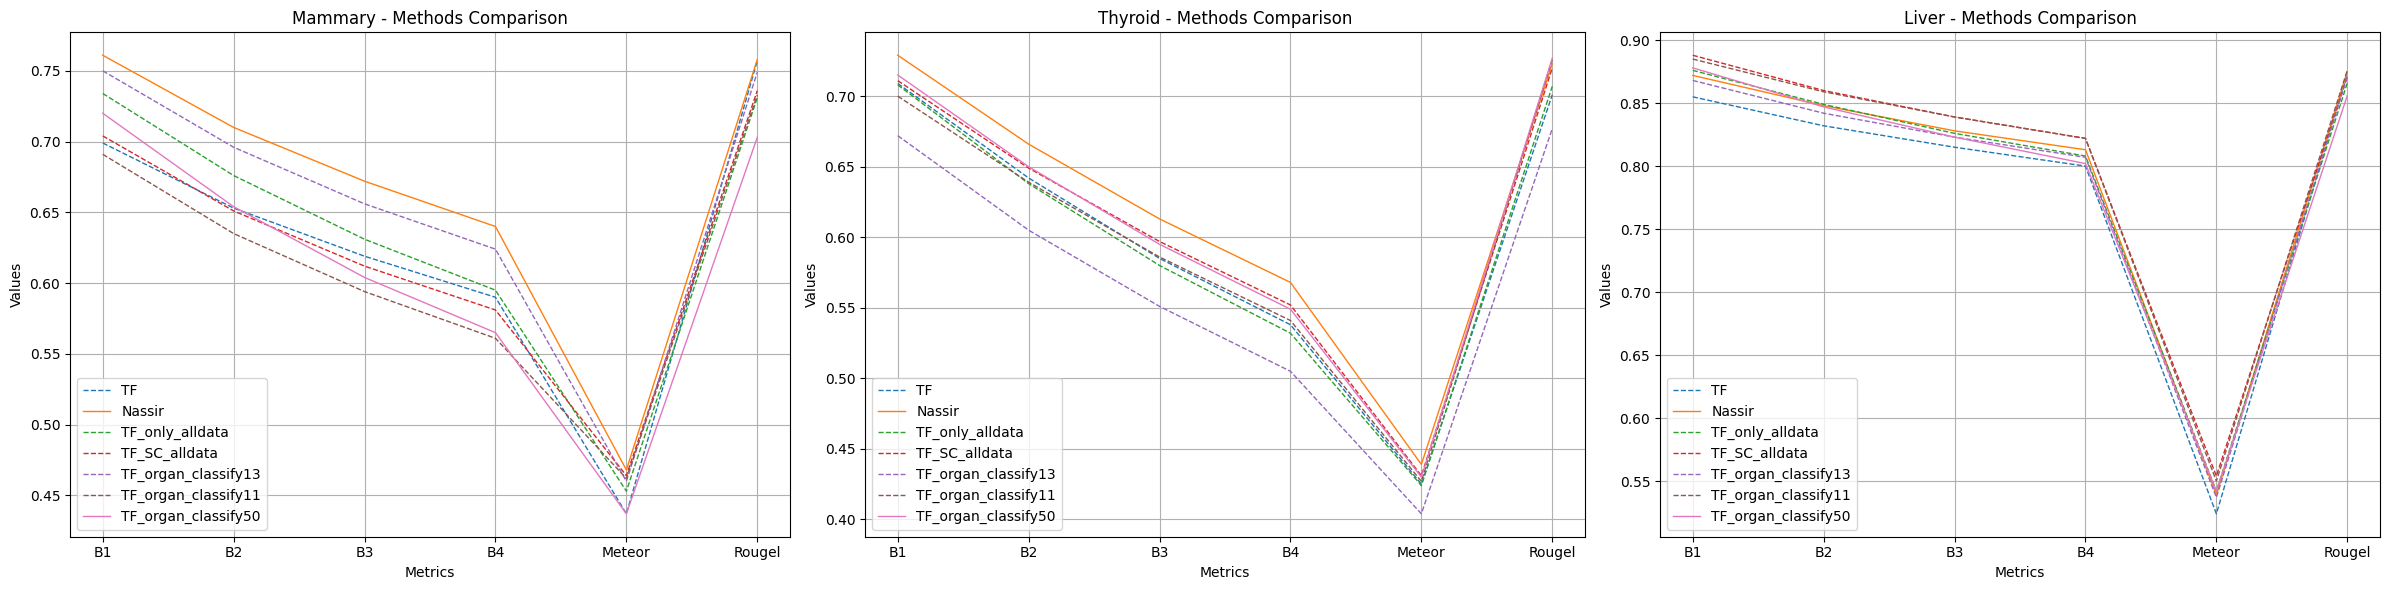

In [49]:
# 获取唯一的器官名称
organs = df['Dataset'].unique()

    
    
# 创建一个包含三个子图的图形
# 获取唯一的器官名称
organs = df['Dataset'].unique()
fig, axs = plt.subplots(1, 3, figsize=(24, 6))

# 为每个器官绘制图表
for i, organ in enumerate(organs):
    # 筛选出当前器官的数据
    organ_data = df[df['Dataset'] == organ]
    
    # 绘制每个方法的曲线
    for method in organ_data['Method']:
        method_data = organ_data[organ_data['Method'] == method]
        if 'Nassir' == method:
            axs[i].plot(method_data.columns[2:], method_data.iloc[0, 2:], label=method, linewidth=1)
        elif '50' in method:
            axs[i].plot(method_data.columns[2:], method_data.iloc[0, 2:], label=method, linewidth=1,linestyle='-')
        elif 'TF' in method:
            axs[i].plot(method_data.columns[2:], method_data.iloc[0, 2:], label=method, linewidth=1,linestyle='--')
        # else:
        #     axs[i].plot(method_data.columns[2:], method_data.iloc[0, 2:], label=method)
    
    # 添加标题和标签
    axs[i].set_title(f'{organ} - Methods Comparison')
    axs[i].set_xlabel('Metrics')
    axs[i].set_ylabel('Values')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()

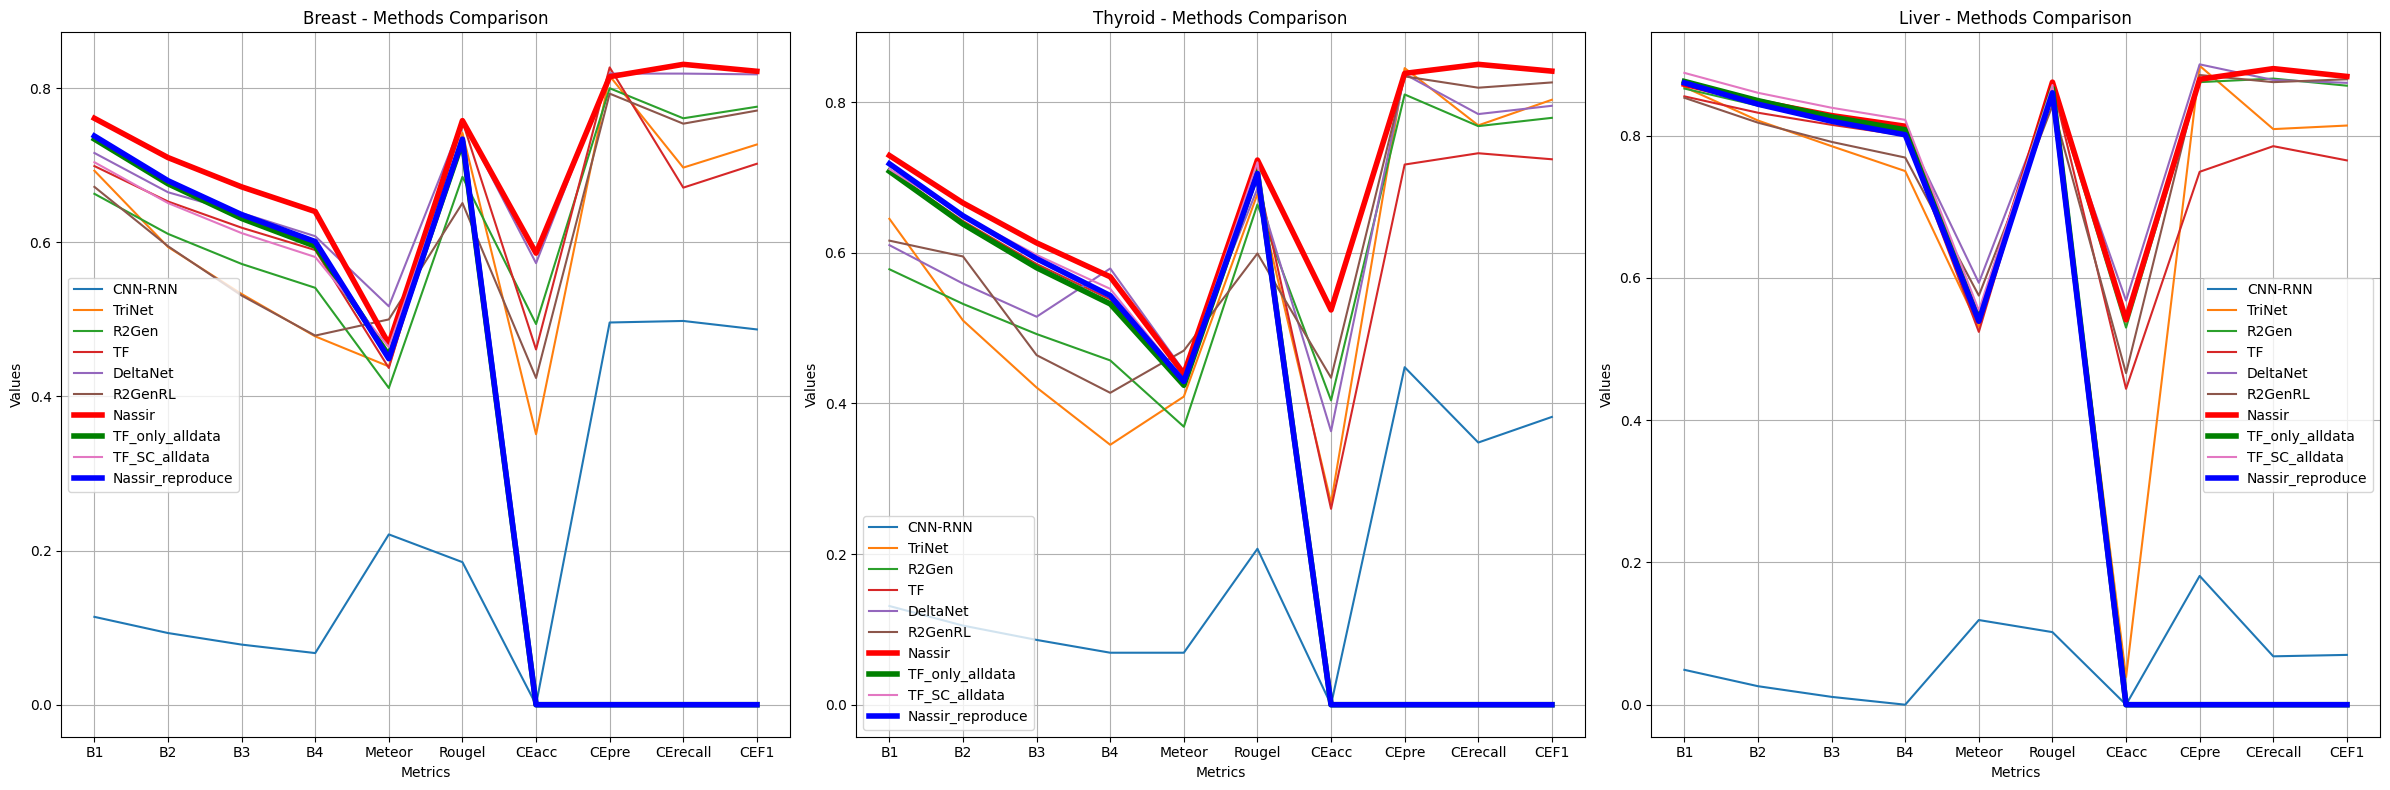

In [6]:
# 获取唯一的器官名称
organs = df['Dataset'].unique()

# 为每个器官绘制图表
# for organ in organs:
#     # 筛选出当前器官的数据
#     organ_data = df[df['Dataset'] == organ]
    
#     # 设置图表大小
#     plt.figure(figsize=(12, 8))
    
#     # 绘制每个方法的曲线
#     for method in organ_data['Method']:
#         method_data = organ_data[organ_data['Method'] == method]
#         if method in ['TF_only_alldata', 'Nassir']:
#             plt.plot(method_data.columns[2:], method_data.iloc[0, 2:], label=method, linewidth=4)
#         else:
#             plt.plot(method_data.columns[2:], method_data.iloc[0, 2:], label=method)
    
#     # 添加标题和标签
#     plt.title(f'{organ} - Methods Comparison')
#     plt.xlabel('Metrics')
#     plt.ylabel('Values')
#     plt.legend()
#     plt.grid(True)
    
    
# 创建一个包含三个子图的图形
# 获取唯一的器官名称
organs = df['Dataset'].unique()
fig, axs = plt.subplots(1, 3, figsize=(24, 8))

# 为每个器官绘制图表
for i, organ in enumerate(organs):
    # 筛选出当前器官的数据
    organ_data = df[df['Dataset'] == organ]
    
    # 绘制每个方法的曲线
    for method in organ_data['Method']:
        method_data = organ_data[organ_data['Method'] == method]
        # if method in ['TF_only_alldata', 'Nassir', 'TF_SC_alldata']:
        #     axs[i].plot(method_data.columns[2:], method_data.iloc[0, 2:], label=method, linewidth=4)
        if method in ['Nassir',]:
            axs[i].plot(method_data.columns[2:], method_data.iloc[0, 2:], label=method, color='red', linewidth=4)
        elif method in ['Nassir_reproduce']:
            axs[i].plot(method_data.columns[2:], method_data.iloc[0, 2:], label=method, color='blue', linewidth=4)
        elif method in ['TF_only_alldata']:
            axs[i].plot(method_data.columns[2:], method_data.iloc[0, 2:], label=method, color='green', linewidth=4)
        else:
            axs[i].plot(method_data.columns[2:], method_data.iloc[0, 2:], label=method)
    
    # 添加标题和标签
    axs[i].set_title(f'{organ} - Methods Comparison')
    axs[i].set_xlabel('Metrics')
    axs[i].set_ylabel('Values')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()

**查看数据的train、val、test的文本类型分布是不是合理的，避免split不合理**

In [38]:
import json
import matplotlib.pyplot as plt
from collections import Counter

def count_labels_by_split(json_path):
    with open(json_path, "r", encoding="utf-8-sig") as f:
        data = json.load(f)
    
    label_counts = {}
    all_labels_counter = Counter()
    
    for split in ["train", "val", "test"]:
        if split in data:
            # print(f"split = {split}")
            labels = [item["labels"] for item in data[split]]
            tmp = dict(Counter(labels))
            sorted_dict = dict(sorted(tmp.items(), key=lambda item: item[1], reverse=True))
            label_counts[split] = sorted_dict
            # print(f"split = {split}, label_counts[split] = {label_counts[split]}")  # {1: 666, 4: 284, 3: 149, 12: 无序的
            all_labels_counter.update(labels)
        
    # 按总频次排序的标签列表
    sorted_labels = [label for label, _ in all_labels_counter.most_common()]
    # print(sorted_labels)

    return label_counts, sorted_labels


def plot_label_distribution(label_distribution, sorted_labels):
    plt.figure(figsize=(10, 6))
    
    for split, counts in label_distribution.items():
        sorted_counts = [counts.get(label, 0) for label in sorted_labels]
        plt.plot(range(len(sorted_labels)), sorted_counts, marker='o', label=split)
    
    # print(sorted_labels)
    labels = [str(i) for i in sorted_labels]
    # print(f"labels = {labels}")
    plt.xlabel("Label ID (sorted by frequency)")
    plt.xticks(range(len(sorted_labels)), labels)
    plt.ylabel("Frequency")
    plt.title("Label Distribution Across Splits")
    plt.legend()
    plt.grid()
    plt.show()


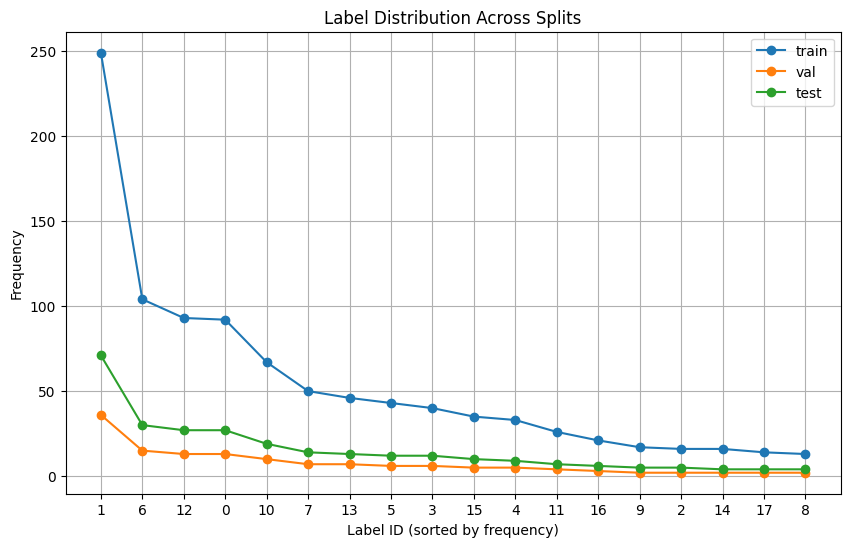

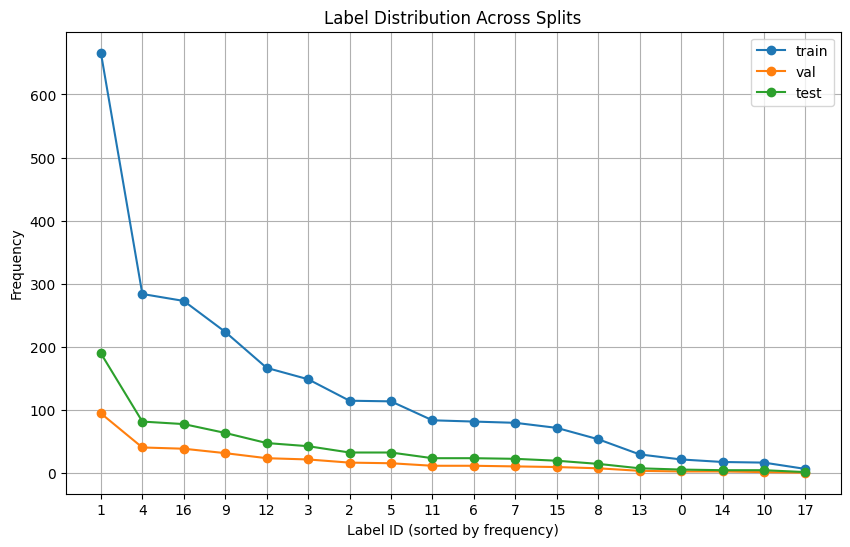

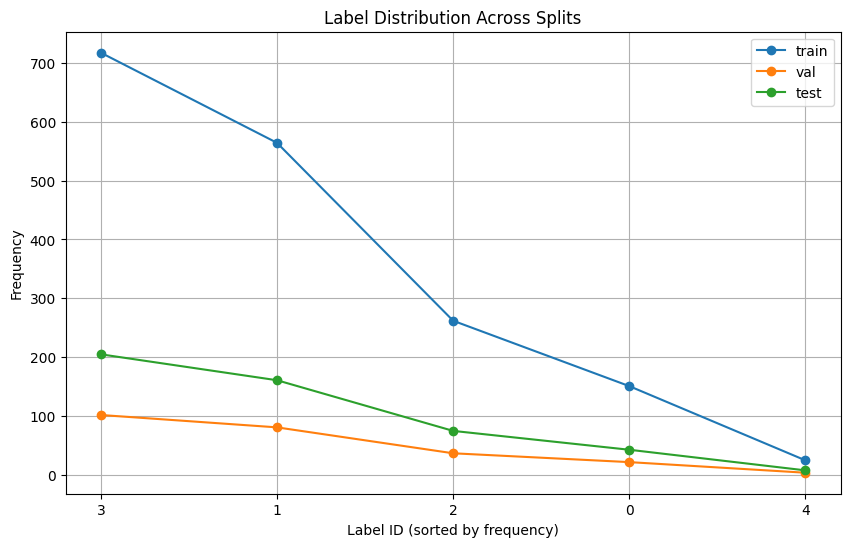

In [39]:
for organ in ['Liver', 'Mammary', 'Thyroid']:
    json_path = f"../USData/new_{organ}2.json"
    label_distribution, sorted_labels = count_labels_by_split(json_path)
    plot_label_distribution(label_distribution, sorted_labels)